In [1]:
# Data handling
import pandas as pd 
import numpy as np 

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold

# Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import ( LinearRegression,Ridge,Lasso,ElasticNet)
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.svm import SVR, SVC

# Metrics

from sklearn.metrics import r2_score ,accuracy_score

#save models
import pickle



# load Dataset

In [2]:
# load Dataset

df = pd.read_csv("../dataset/student_data_.csv")

# first 5 rows 
df.head()

,Name,Class 10th Percentage (%),Class 12th Percentage (%),Mathematics-I [T],Applied Physics-I [T],Applied Chemistry [T],Communication Skills [T],Applied Physics-I [P],Applied Chemistry [P],Communication Skills [P],...,Software Testing [T],Project Management [T],Artificial Intelligence [T],Mobile Computing [P],Software Testing [P],Major Project [P],Seminar,Semester-VI (SGPA),final_cgpa,Information Security [P]
0,Student_1,79.16,86.24,C+,A,A+,A+,A,A+,B,...,B,C,B+,C,B+,A+,B,9.45,NaN,B
1,Student_2,60.76,92.90,C+,C,A,B,A,A,B,...,B,C+,A,C,A,B,B+,7.71,NaN,A
2,Student_3,60.20,89.53,C,A,A+,A+,A,B,A,...,A+,A+,C,C,C,C,C+,6.16,NaN,A+
3,Student_4,86.05,64.42,A,C,C,C,B,A,B+,...,A,C+,B,B,B+,A,A,6.10,NaN,C+
4,Student_5,63.11,78.80,A+,A,A,C+,C+,A,C+,...,B+,B,C+,A,C,C,C+,8.89,NaN,B


# Basic information

In [3]:
# Basic information

# structure of dataset 
df.info()

# statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 65 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Name                                                        1000 non-null   object 
 1   Class 10th Percentage (%)                                   1000 non-null   float64
 2   Class 12th Percentage (%)                                   1000 non-null   float64
 3   Mathematics-I [T]                                           1000 non-null   object 
 4   Applied Physics-I [T]                                       1000 non-null   object 
 5   Applied Chemistry [T]                                       1000 non-null   object 
 6   Communication Skills [T]                                    1000 non-null   object 
 7   Applied Physics-I [P]                                       1000 non-null   object 
 8  

,Class 10th Percentage (%),Class 12th Percentage (%),Semester-I (SGPA),Semester-II (SGPA),Semester-III (SGPA),Semester-IV (SGPA),Semester-V (SGPA),Semester-VI (SGPA),final_cgpa
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,0.0
mean,77.648400,77.590080,7.894580,7.896110,7.85898,7.880470,7.884670,7.928880,NaN
std,10.058368,10.087494,1.112469,1.099513,1.10204,1.097434,1.086475,1.085521,NaN
min,60.010000,60.080000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,NaN
25%,68.885000,68.572500,6.960000,6.950000,6.91000,6.880000,6.910000,6.980000,NaN
50%,78.285000,77.955000,7.830000,7.890000,7.83000,7.890000,7.900000,7.980000,NaN
75%,86.147500,85.837500,8.860000,8.862500,8.82000,8.795000,8.800000,8.860000,NaN
max,95.000000,95.000000,9.800000,9.800000,9.79000,9.790000,9.800000,9.790000,NaN


In [4]:
print(df.columns.tolist())

['Name', 'Class 10th Percentage (%)', 'Class 12th Percentage (%)', 'Mathematics-I [T]', 'Applied Physics-I [T]', 'Applied Chemistry [T]', 'Communication Skills [T]', 'Applied Physics-I [P]', 'Applied Chemistry [P]', 'Communication Skills [P]', 'Engineering Graphics [P]', 'Engineering Workshop Practice [P]', 'Sports and Yoga [P]', 'Semester-I (SGPA)', 'Mathematics-II [T]', 'Applied Physics-II [T]', 'Introduction to IT Systems [T]', 'Fundamentals of Electrical and Electronics Engineering [T]', 'Engineering Mechanics [T]', 'Applied Physics-II [P]', 'Introduction to IT Systems [P]', 'Fundamentals of Electrical and Electronics Engineering [P]', 'Engineering Mechanics [P]', 'Semester-II (SGPA)', 'Computer Programming [T]', 'Scripting Languages [T]', 'Data Structures [T]', 'Computer System Organisation [T]', 'Algorithms [T]', 'Computer Programming [P]', 'Scripting Languages [P]', 'Data Structures [P]', 'Summer Internship-I', 'Semester-III (SGPA)', 'Operating Systems [T]', 'Introduction to DBM

# Data Cleaning

In [5]:
# Percentage Cleaning

df['Class 10th Percentage (%)'] = df['Class 10th Percentage (%)'].astype(float)
df['Class 12th Percentage (%)'] = df['Class 12th Percentage (%)'].astype(float)

In [6]:
# Rename SGPA Columns

df = df.rename(columns={
    'Semester-I (SGPA)': 'sem1',
    'Semester-II (SGPA)': 'sem2',
    'Semester-III (SGPA)': 'sem3',
    'Semester-IV (SGPA)': 'sem4',
    'Semester-V (SGPA)': 'sem5',
    'Semester-VI (SGPA)': 'sem6'
})
df

,Name,Class 10th Percentage (%),Class 12th Percentage (%),Mathematics-I [T],Applied Physics-I [T],Applied Chemistry [T],Communication Skills [T],Applied Physics-I [P],Applied Chemistry [P],Communication Skills [P],...,Software Testing [T],Project Management [T],Artificial Intelligence [T],Mobile Computing [P],Software Testing [P],Major Project [P],Seminar,sem6,final_cgpa,Information Security [P]
0,Student_1,79.16,86.24,C+,A,A+,A+,A,A+,B,...,B,C,B+,C,B+,A+,B,9.45,NaN,B
1,Student_2,60.76,92.90,C+,C,A,B,A,A,B,...,B,C+,A,C,A,B,B+,7.71,NaN,A
2,Student_3,60.20,89.53,C,A,A+,A+,A,B,A,...,A+,A+,C,C,C,C,C+,6.16,NaN,A+
3,Student_4,86.05,64.42,A,C,C,C,B,A,B+,...,A,C+,B,B,B+,A,A,6.10,NaN,C+
4,Student_5,63.11,78.80,A+,A,A,C+,C+,A,C+,...,B+,B,C+,A,C,C,C+,8.89,NaN,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Student_996,61.39,87.56,B,B,B,A,A,A,A+,...,B,A,A,A,A+,A,A,6.74,NaN,C+
996,Student_997,91.48,66.65,C+,C+,C,C,B,C+,A+,...,B,B+,A,A,A+,C+,B+,8.03,NaN,C
997,Student_998,71.71,86.24,C+,A+,C+,C+,B,C,A,...,C+,B,A+,A,B+,C,A,7.51,NaN,C+
998,Student_999,91.82,77.77,C,A,B+,A+,C,C,A,...,B+,B+,A+,B,A,B+,A,7.36,NaN,B+


# EDA(Graph)

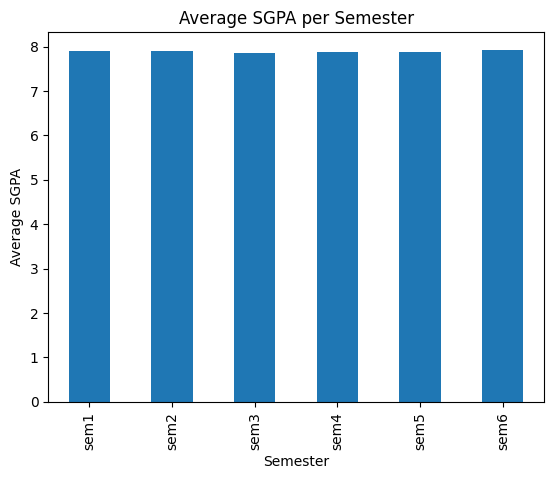

In [7]:
# Semester-wise SGPA Graph

sem_cols = ['sem1','sem2','sem3','sem4','sem5','sem6']

df[sem_cols].mean().plot(kind='bar')

plt.title("Average SGPA per Semester")
plt.xlabel("Semester")
plt.ylabel("Average SGPA")
plt.show()

# Target Creation

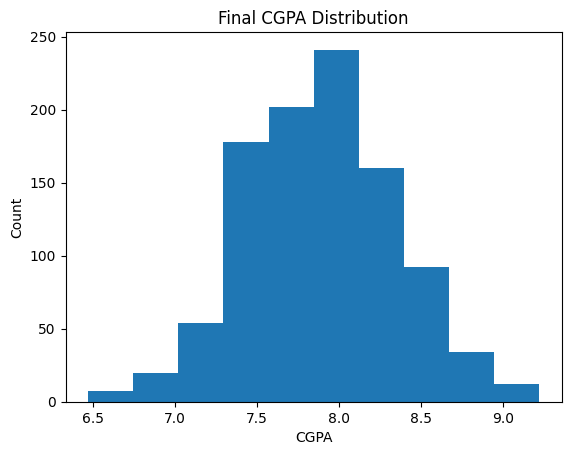

In [8]:
# Final CGPA

df['final_cgpa'] = df[['sem1','sem2','sem3','sem4','sem5','sem6']].mean(axis=1)


# CGPA Distribution (Histogram)

plt.figure()
plt.hist(df['final_cgpa'], bins=10)
plt.title("Final CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Count")
plt.show()

In [9]:
# Performance Category

def perf(cgpa):
    if cgpa >= 8:
        return "Excellent"
    elif cgpa >= 6:
        return "Good"
    else:
        return "Average"

df['performance'] = df['final_cgpa'].apply(perf)
df.head()

,Name,Class 10th Percentage (%),Class 12th Percentage (%),Mathematics-I [T],Applied Physics-I [T],Applied Chemistry [T],Communication Skills [T],Applied Physics-I [P],Applied Chemistry [P],Communication Skills [P],...,Project Management [T],Artificial Intelligence [T],Mobile Computing [P],Software Testing [P],Major Project [P],Seminar,sem6,final_cgpa,Information Security [P],performance
0,Student_1,79.16,86.24,C+,A,A+,A+,A,A+,B,...,C,B+,C,B+,A+,B,9.45,7.980000,B,Good
1,Student_2,60.76,92.90,C+,C,A,B,A,A,B,...,C+,A,C,A,B,B+,7.71,8.308333,A,Excellent
2,Student_3,60.20,89.53,C,A,A+,A+,A,B,A,...,A+,C,C,C,C,C+,6.16,8.025000,A+,Excellent
3,Student_4,86.05,64.42,A,C,C,C,B,A,B+,...,C+,B,B,B+,A,A,6.10,6.743333,C+,Good
4,Student_5,63.11,78.80,A+,A,A,C+,C+,A,C+,...,B,C+,A,C,C,C+,8.89,8.468333,B,Excellent


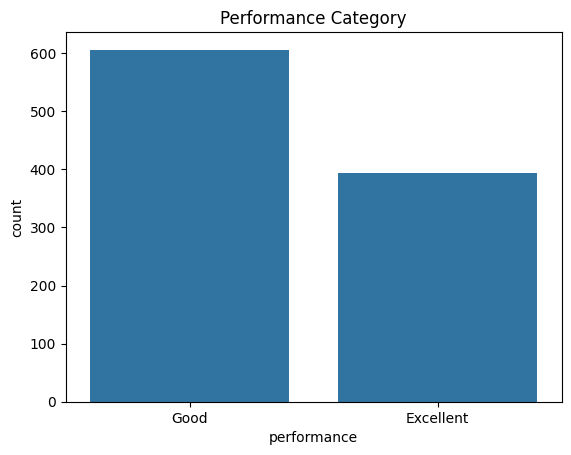

In [10]:
sns.countplot(x=df['performance'])

plt.title("Performance Category")
plt.show()

#  Leakage free Feature Selection

In [11]:
# Final CGPA Prediction

y_cgpa = df['final_cgpa']
X_cgpa = df[
    [
        'Class 10th Percentage (%)',
        'Class 12th Percentage (%)',
        'sem1',
        'sem2',
        'sem3',
        'sem4',
        'sem5'   
    ]
]


In [12]:
#Next Semester SGPA Prediction


y_sgpa = df['sem6']

X_sgpa = df[
    [
        'Class 10th Percentage (%)',
        'Class 12th Percentage (%)',
        'sem1',
        'sem2',
        'sem3',
        'sem4',
        'sem5'
    ]
]

# encoding (now only for performance category )

In [13]:
from sklearn.preprocessing import LabelEncoder

perf_encoder = LabelEncoder()

df['perf_enc'] = perf_encoder.fit_transform(df['performance'])

In [14]:
# Performance Category


y_perf = df['perf_enc']


X_perf = df[
    [
        'Class 10th Percentage (%)',
        'Class 12th Percentage (%)',
        'sem1',
        'sem2',
        'sem3',
        'sem4',
        'sem5'
    ]
]

# Subject Data (MELT)

In [15]:
subject_cols = [

    col for col in df.columns

    if (
        '[T]' in col
        or '[P]' in col
        or 'Internship' in col
        or 'Project' in col
        or 'Security' in col
    )
]

df_sub = df.melt(
    id_vars=['Class 10th Percentage (%)','Class 12th Percentage (%)',
    'sem1','sem2','sem3','sem4','sem5','sem6'],
    value_vars=subject_cols,
    var_name='subject',
    value_name='grade'
)

# missing value remove 
df_sub.dropna(inplace=True)


df_sub.head()

,Class 10th Percentage (%),Class 12th Percentage (%),sem1,sem2,sem3,sem4,sem5,sem6,subject,grade
0,79.16,86.24,7.71,9.30,7.21,7.90,6.31,9.45,Mathematics-I [T],C+
1,60.76,92.90,8.67,9.51,7.96,8.10,7.90,7.71,Mathematics-I [T],C+
2,60.20,89.53,9.20,9.10,8.27,7.20,8.22,6.16,Mathematics-I [T],C
3,86.05,64.42,6.96,7.62,6.31,7.26,6.21,6.10,Mathematics-I [T],A
4,63.11,78.80,8.41,7.60,7.76,8.35,9.80,8.89,Mathematics-I [T],A+


# Encoding

In [16]:
# Subject encoder
sub_enc = LabelEncoder()
df_sub['subject_enc'] = sub_enc.fit_transform(df_sub['subject'])

# Grade mapping
grade_map = {
    "A+":10,"A":9,"B+":8,"B":7,
    "C+":6,"C":5,"D+":4,"D":3
}

df_sub['grade_num'] = df_sub['grade'].map(grade_map)



# Outlier Detection(numeric only)

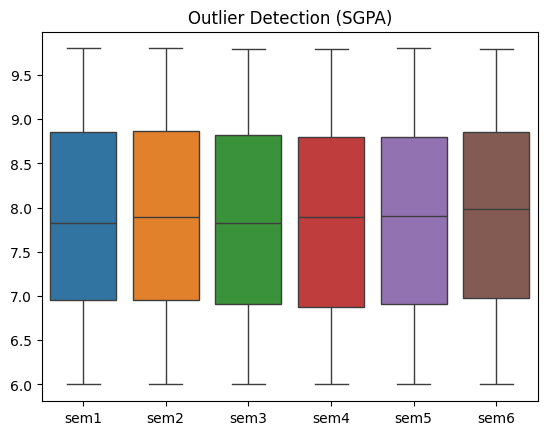

In [17]:
plt.figure()

sns.boxplot(data=df[['sem1','sem2','sem3','sem4','sem5','sem6']])

plt.title("Outlier Detection (SGPA)")
plt.show()




# Feature Engineering

In [18]:
df['avg_sgpa'] = df[['sem1','sem2','sem3','sem4','sem5']].mean(axis=1)
df['trend'] = df['sem5'] - df['sem1']

In [19]:
X = df[['Class 10th Percentage (%)','Class 12th Percentage (%)',
        'avg_sgpa','trend']]

# Feature Selection

In [20]:
X = df[['Class 10th Percentage (%)','Class 12th Percentage (%)',
        'sem1','sem2','sem3','sem4','sem5']]

y_cgpa = df['final_cgpa']
y_perf = df['perf_enc']

y_cgpa.head()
y_perf.head()

0    1
1    0
2    0
3    1
4    0
Name: perf_enc, dtype: int64

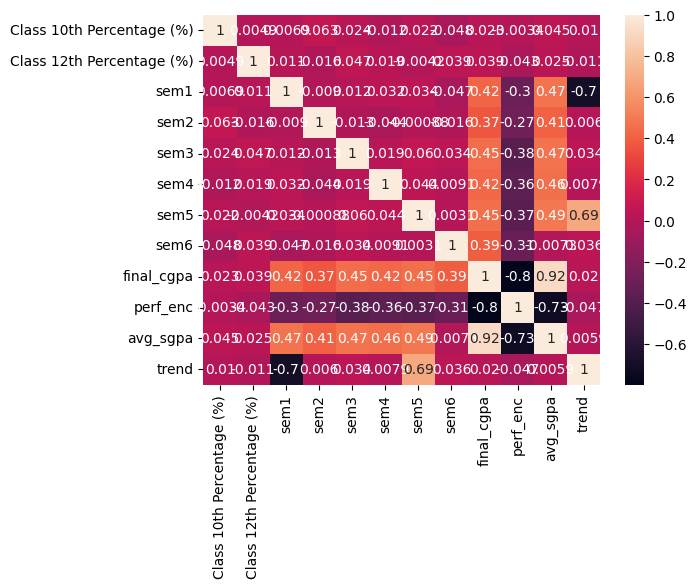

In [21]:
#Correlation

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# Train Test Split

In [22]:

# CGPA (Regression)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cgpa, test_size=0.2, random_state=42
)


# SGPA (Regression)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sgpa, y_sgpa, test_size=0.2, random_state=42
)


# PERFORMANCE (Classification)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_perf, test_size=0.2, random_state=42, stratify=y_perf
)

print("✅ Train-Test Split Done")

✅ Train-Test Split Done


# Scaling

In [23]:

# SCALING (Only CGPA + Performance)



scaler = StandardScaler()

# CGPA
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SGPA (separate scaler)
scaler_sgpa = StandardScaler()
X_train_s_scaled = scaler_sgpa.fit_transform(X_train_s)
X_test_s_scaled = scaler_sgpa.transform(X_test_s)

print("✅ Scaling Done")

✅ Scaling Done


# Model training

In [24]:




models = {

    # LINEAR MODELS
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.01),

    "ElasticNet Regression": ElasticNet(
        alpha=0.01,
        l1_ratio=0.5
    ),

    # OTHER MODELS
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "SVR": SVR(
        kernel='rbf',
        C=100
    )
}

# ---------------------------------------------------------
# CROSS VALIDATION
# ---------------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------------------------
# TRAINING + EVALUATION
# ---------------------------------------------------------

best_model = None
best_score = -999
best_name = ""

results = []

for name, model in models.items():

    # TRAIN
    model.fit(X_train_scaled, y_train)

    # PREDICTION
    pred = model.predict(X_test_scaled)

    # TEST SCORE
    r2 = r2_score(y_test, pred)

    # CROSS VALIDATION SCORE
    cv_score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv
    ).mean()

    # PRINT RESULT
    print(f"\n{name}")
    print("Test R2:", round(r2, 4))
    print("CV Score:", round(cv_score, 4))

    # STORE RESULTS
    results.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "CV Score": round(cv_score, 4)
    })

    # BEST MODEL
    if r2 > best_score:
        best_score = r2
        best_model = model
        best_name = name

# ---------------------------------------------------------
# FINAL RESULT
# ---------------------------------------------------------

print("\n🏆 Best Model:", best_name)
print("Best R2 Score:", round(best_score, 4))


Linear Regression
Test R2: 0.851
CV Score: 0.8359

Ridge Regression
Test R2: 0.8509
CV Score: 0.8359

Lasso Regression
Test R2: 0.8457
CV Score: 0.8332

ElasticNet Regression
Test R2: 0.8484
CV Score: 0.8349

Decision Tree
Test R2: 0.5301
CV Score: 0.5204

Random Forest
Test R2: 0.7868
CV Score: 0.7662

SVR
Test R2: 0.7218
CV Score: 0.6375

🏆 Best Model: Linear Regression
Best R2 Score: 0.851


In [25]:
results = []

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, pred)
    
    cv = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "CV Score": cv
    })

results_df = pd.DataFrame(results)

# save results
results_df.to_csv("../models/model_results.csv", index=False)

# Save Model + Scaler

In [ ]:
import os
import pickle

os.makedirs("../models", exist_ok=True)


# 1. CGPA MODEL

pickle.dump(best_model, open("../models/cgpa_model.pkl", "wb"))


# 2. SGPA MODEL

sgpa_model = SVR(C=100)
sgpa_model.fit(X_train_s_scaled, y_train_s)

pickle.dump(sgpa_model, open("../models/sgpa_model.pkl", "wb"))


# 3. PERFORMANCE MODEL

perf_model = RandomForestClassifier(n_estimators=200, random_state=42)
perf_model.fit(X_train_scaled, y_train_p)

pickle.dump(perf_model, open("../models/perf_model.pkl", "wb"))


# 4. GRADE MODEL



X_grade = df_sub[
    [
        'Class 10th Percentage (%)',
        'Class 12th Percentage (%)',
        'sem1',
        'sem2',
        'sem3',
        'sem4',
        'sem5',
        'subject_enc'
    ]
]

y_grade = df_sub['grade_num']

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_grade,
    y_grade,
    test_size=0.2,
    random_state=42
)

# RANDOM FOREST MODEL
grade_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

grade_model.fit(Xg_train, yg_train)

# SAVE MODEL
pickle.dump(
    grade_model,
    open("../models/grade_model.pkl", "wb")
)

# 5. SCALER

pickle.dump(scaler, open("../models/scaler.pkl", "wb"))




# 6. ENCODERS

pickle.dump(sub_enc, open("../models/subject_encoder.pkl", "wb"))
pickle.dump(perf_encoder, open("../models/perf_encoder.pkl", "wb"))


# 7. GRADE MAP 

pickle.dump(grade_map, open("../models/grade_map.pkl", "wb"))

print("✅ ALL models saved correctly")

✅ ALL models saved correctly


In [27]:
print(df_sub['grade'].value_counts())

grade
C     9128
A     9057
B     8999
A+    8961
B+    8928
C+    8927
Name: count, dtype: int64
